# PrimeTrade.ai Data Science Assignment

### Candidate: Alokesh Ghosh

### Objective
Analyze the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using Hyperliquid historical trading data. The goal is to uncover patterns, generate insights, and recommend data-driven trading strategies.

---

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Plot style
plt.style.use('ggplot')

print("Libraries imported successfully!")

Libraries imported successfully!


In [75]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'historical_data.csv', 'fear_greed_index - fear_greed_index.csv', 'sample_data']


In [76]:
import os

print(os.listdir("/content"))

['.config', 'historical_data.csv', 'fear_greed_index - fear_greed_index.csv', 'sample_data']


In [77]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

Current Working Directory:
/content

Files in current directory:
['.config', 'historical_data.csv', 'fear_greed_index - fear_greed_index.csv', 'sample_data']


In [78]:
print("\nFiles in /content:")
print(os.listdir("/content"))


Files in /content:
['.config', 'historical_data.csv', 'fear_greed_index - fear_greed_index.csv', 'sample_data']


In [79]:
import pandas as pd

# Load trader data (skip malformed rows)
trades = pd.read_csv(
    "historical_data.csv",
    engine="python",
    on_bad_lines="skip"
)

# Load sentiment data
sentiment = pd.read_csv("fear_greed_index - fear_greed_index.csv")

print("Trader Dataset Shape:", trades.shape)
print("Sentiment Dataset Shape:", sentiment.shape)

Trader Dataset Shape: (75702, 16)
Sentiment Dataset Shape: (2644, 4)


In [80]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.003055,1.050000e+15,1.730000e+12


In [81]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75702 entries, 0 to 75701
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           75702 non-null  object 
 1   Coin              75702 non-null  object 
 2   Execution Price   75702 non-null  object 
 3   Size Tokens       75702 non-null  float64
 4   Size USD          75701 non-null  object 
 5   Side              75701 non-null  object 
 6   Timestamp IST     75700 non-null  object 
 7   Start Position    75700 non-null  float64
 8   Direction         75699 non-null  object 
 9   Closed PnL        75698 non-null  float64
 10  Transaction Hash  75698 non-null  object 
 11  Order ID          75698 non-null  float64
 12  Crossed           75697 non-null  object 
 13  Fee               75697 non-null  float64
 14  Trade ID          75696 non-null  float64
 15  Timestamp         75696 non-null  float64
dtypes: float64(7), object(9)
memory usage: 9

In [82]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [83]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


# 1. Data Loading and Initial Exploration

In this section, we inspect the datasets, understand their structure, identify missing values, and prepare them for analysis.

# 2. Data Cleaning

In this section, we clean the datasets, check for duplicates, convert date columns to the correct format, and prepare the data for merging.

In [84]:
import pandas as pd

trades = pd.read_csv(
    "historical_data.csv",
    on_bad_lines="skip"
)

sentiment = pd.read_csv("fear_greed_index - fear_greed_index.csv")

print(trades.shape)
print(sentiment.shape)

(75702, 16)
(2644, 4)


/tmp/ipykernel_501/306656759.py:3: DtypeWarning: Columns (2,4,12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv(


In [85]:
import pandas as pd

trades = pd.read_csv(
    "historical_data.csv",
    engine="python",
    on_bad_lines="skip"
)

sentiment = pd.read_csv("fear_greed_index - fear_greed_index.csv")

print(trades.shape)

(75702, 16)


In [86]:
# First 5 rows
display(trades.head())
display(sentiment.head())

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.003055,1.050000e+15,1.730000e+12


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [87]:
print("Trader Columns:")
print(trades.columns)

print("\nSentiment Columns:")
print(sentiment.columns)

Trader Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Sentiment Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [88]:
print("Missing Values in Trader Dataset")
print(trades.isnull().sum())

print("\nMissing Values in Sentiment Dataset")
print(sentiment.isnull().sum())

Missing Values in Trader Dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            1
Side                1
Timestamp IST       2
Start Position      2
Direction           3
Closed PnL          4
Transaction Hash    4
Order ID            4
Crossed             5
Fee                 5
Trade ID            6
Timestamp           6
dtype: int64

Missing Values in Sentiment Dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [89]:
trades.describe(include='all')

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,75702,75702,75702,7.570200e+04,75701,75701,75700,7.570000e+04,75699,7.569800e+04,75698,7.569800e+04,75697,7.569700e+04,7.569600e+04,7.569600e+04
unique,17,146,20334,NaN,52719,5,6204,NaN,13,NaN,26970,NaN,3,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,0.59,NaN,499.97,SELL,14-02-2025 00:31,NaN,Close Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,TRUE,NaN,NaN,NaN
freq,23150,24620,390,NaN,122,38289,441,NaN,20417,NaN,1390,NaN,51976,NaN,NaN,NaN
mean,NaN,NaN,NaN,2.393852e+07,NaN,NaN,NaN,2.373539e+07,NaN,1.086822e+06,NaN,7.341543e+10,NaN,2.298638e+07,5.639194e+14,1.739194e+12
std,NaN,NaN,NaN,6.329404e+09,NaN,NaN,NaN,6.327492e+09,NaN,2.990001e+08,NaN,1.964859e+10,NaN,6.324263e+09,3.254834e+14,8.932332e+09
min,NaN,NaN,NaN,1.000000e-05,NaN,NaN,NaN,-1.433463e+07,NaN,-1.179901e+05,NaN,4.492000e-03,NaN,-1.175712e+00,0.000000e+00,1.710000e+12
25%,NaN,NaN,NaN,6.200000e-01,NaN,NaN,NaN,-8.917998e+02,NaN,0.000000e+00,NaN,6.870817e+10,NaN,3.044000e-02,2.820000e+14,1.740000e+12
50%,NaN,NaN,NaN,2.205000e+01,NaN,NaN,NaN,1.028929e+01,NaN,0.000000e+00,NaN,7.954364e+10,NaN,1.731670e-01,5.620000e+14,1.740000e+12
75%,NaN,NaN,NaN,1.500875e+02,NaN,NaN,NaN,4.567277e+03,NaN,9.901325e+00,NaN,8.626289e+10,NaN,8.622800e-01,8.480000e+14,1.740000e+12


In [90]:
print(trades.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [91]:
trades["Date"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True,
    format="mixed",
    errors="coerce"
).dt.date

In [92]:
print(trades["Date"].isna().sum())

5


In [93]:
sentiment["date"] = pd.to_datetime(
    sentiment["date"],
    dayfirst=True,
    errors="coerce"
).dt.date

print(sentiment.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-01-02
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-03-02
3  1517722200     24   Extreme Fear  2018-04-02
4  1517808600     11   Extreme Fear  2018-05-02


In [94]:
merged = trades.merge(
    sentiment[["date", "classification"]],
    left_on="Date",
    right_on="date",
    how="left"
)

print("Merged Dataset Shape:", merged.shape)
merged.head()

Merged Dataset Shape: (83687, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024-12-02,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024-12-02,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024-12-02,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024-12-02,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024-12-02,Greed


In [95]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83687 entries, 0 to 83686
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           83687 non-null  object 
 1   Coin              83687 non-null  object 
 2   Execution Price   83687 non-null  object 
 3   Size Tokens       83687 non-null  float64
 4   Size USD          82089 non-null  object 
 5   Side              82089 non-null  object 
 6   Timestamp IST     80491 non-null  object 
 7   Start Position    80491 non-null  float64
 8   Direction         78893 non-null  object 
 9   Closed PnL        78892 non-null  float64
 10  Transaction Hash  78892 non-null  object 
 11  Order ID          78892 non-null  float64
 12  Crossed           77294 non-null  object 
 13  Fee               77294 non-null  float64
 14  Trade ID          77293 non-null  float64
 15  Timestamp         77293 non-null  float64
 16  Date              75697 non-null  object

In [96]:
merged["classification"].value_counts(dropna=False)

,count
classification,
NaN,64119
Fear,8221
Greed,5328
Extreme Fear,2123
Extreme Greed,2121
Neutral,1775


In [97]:
avg_pnl = merged.groupby("classification")["Closed PnL"].mean()
print(avg_pnl)

classification
Extreme Fear      -5.298017
Extreme Greed    -28.678776
Fear             216.690980
Greed              2.377033
Neutral           41.516383
Name: Closed PnL, dtype: float64


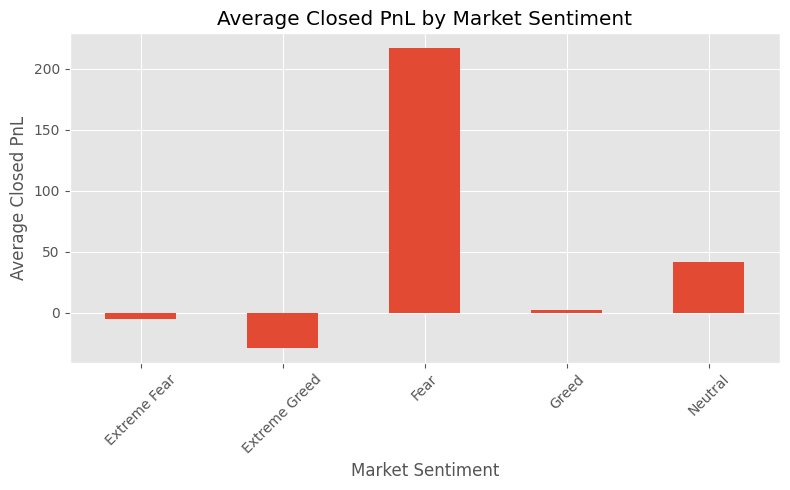

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
avg_pnl.plot(kind="bar")
plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Exploratory Data Analysis (EDA)

This section explores how trader performance changes under different Bitcoin market sentiment conditions.

classification
Fear             8221
Greed            5328
Extreme Fear     2123
Extreme Greed    2121
Neutral          1775
Name: count, dtype: int64


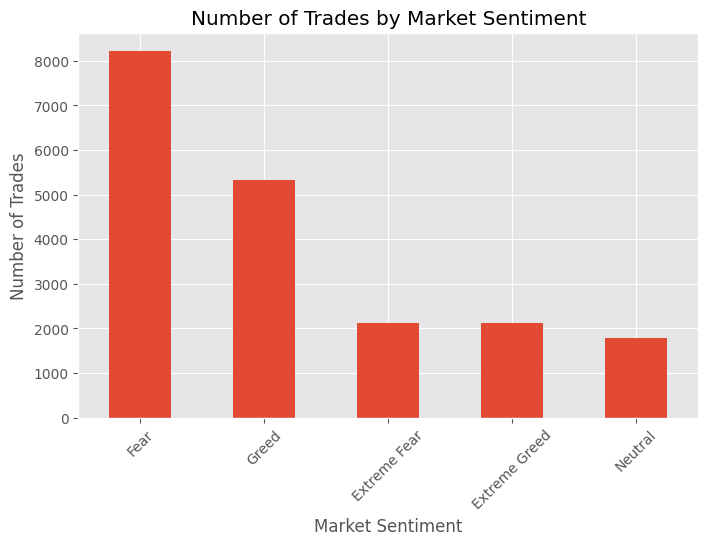

In [99]:
trade_counts = merged["classification"].value_counts()

print(trade_counts)

plt.figure(figsize=(8,5))
trade_counts.plot(kind="bar")
plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

### Observation

This chart shows how trading activity varies across different market sentiment categories.
Higher trade counts indicate increased trader participation during those sentiment conditions.

classification
Extreme Fear      -5.298017
Extreme Greed    -28.678776
Fear             216.690980
Greed              2.377033
Neutral           41.516383
Name: Closed PnL, dtype: float64


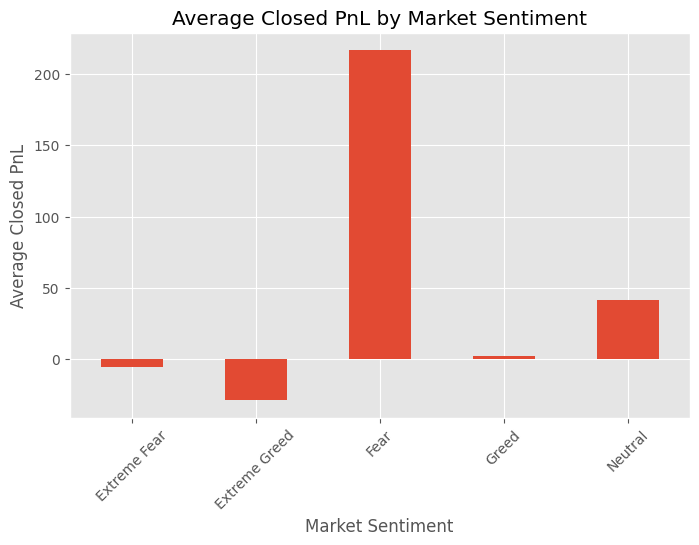

In [100]:
avg_pnl = merged.groupby("classification")["Closed PnL"].mean()

print(avg_pnl)

plt.figure(figsize=(8,5))
avg_pnl.plot(kind="bar")
plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.show()

### Observation

This chart compares the average profit or loss made by traders under different market sentiments.

classification
Extreme Fear    -6.145700e+03
Extreme Greed   -4.396456e+04
Fear             1.488234e+06
Greed            9.947885e+03
Neutral          4.267884e+04
Name: Closed PnL, dtype: float64


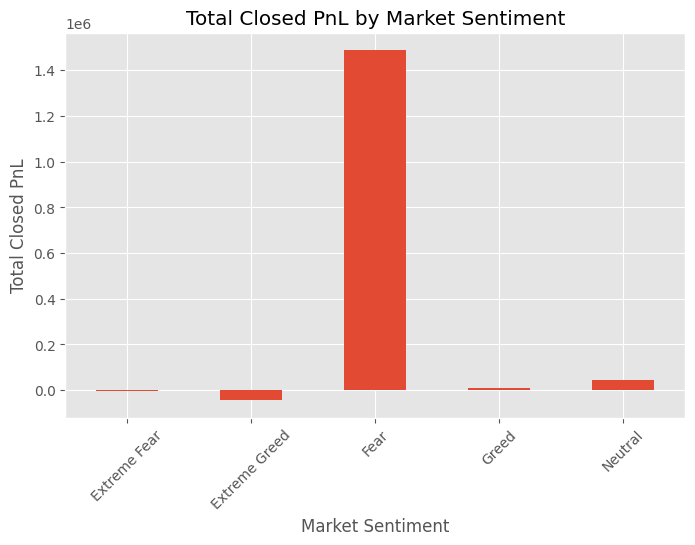

In [101]:
total_pnl = merged.groupby("classification")["Closed PnL"].sum()

print(total_pnl)

plt.figure(figsize=(8,5))
total_pnl.plot(kind="bar")
plt.title("Total Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45)
plt.show()

Side            0.19026  0.83694  1.73E+12   BUY  SELL
classification                                        
Extreme Fear        321      321       321   353   486
Extreme Greed       196      196       196   419   918
Fear                451      451       451  3064  3353
Greed               381      381       381  1746  2058
Neutral             249      249       249   174   605


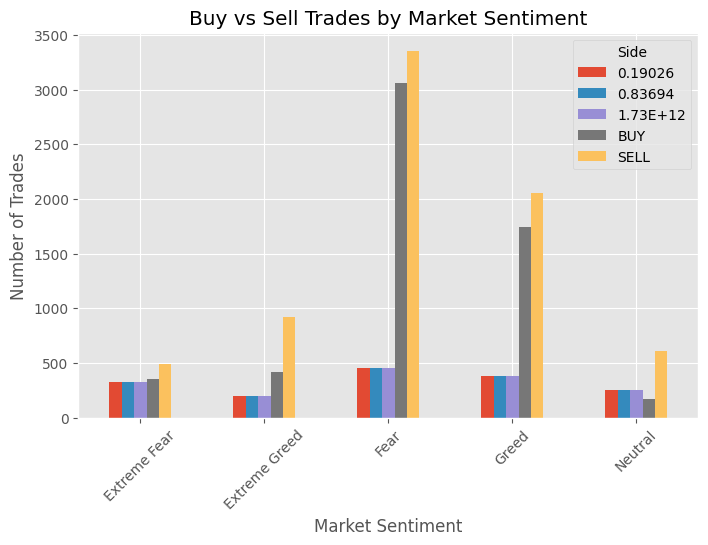

In [102]:
side_counts = pd.crosstab(merged["classification"], merged["Side"])

print(side_counts)

side_counts.plot(kind="bar", figsize=(8,5))
plt.title("Buy vs Sell Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

Coin
LAYER    8.226472e+10
SOL      1.419819e+06
ETH      1.306834e+06
BTC      8.089255e+05
HYPE     4.962840e+05
@107     3.326184e+05
ENA      2.158562e+05
SUI      1.936362e+05
ZRO      1.817290e+05
EIGEN    6.422683e+04
Name: Closed PnL, dtype: float64


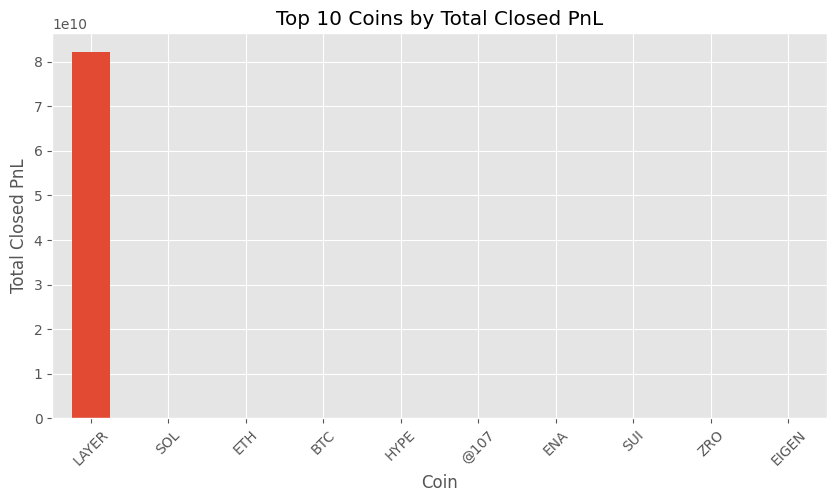

In [103]:
coin_profit = merged.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False).head(10)

print(coin_profit)

plt.figure(figsize=(10,5))
coin_profit.plot(kind="bar")
plt.title("Top 10 Coins by Total Closed PnL")
plt.xlabel("Coin")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45)
plt.show()

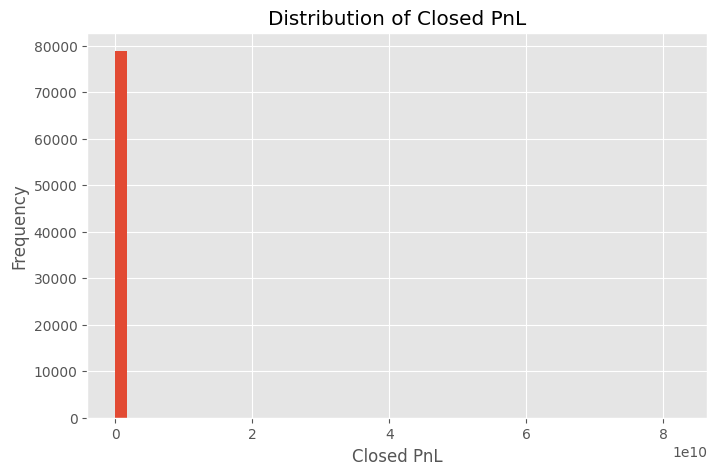

In [104]:
plt.figure(figsize=(8,5))
merged["Closed PnL"].hist(bins=50)
plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")
plt.show()

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

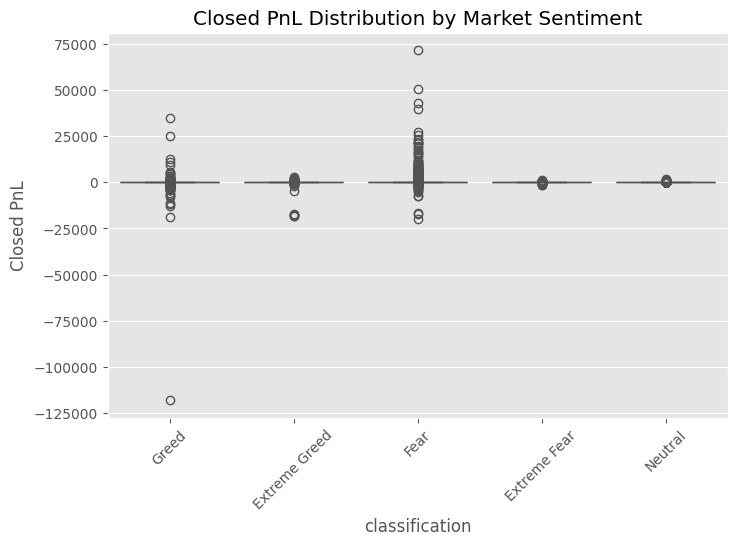

In [106]:
plt.figure(figsize=(8,5))
sns.boxplot(data=merged, x="classification", y="Closed PnL")
plt.xticks(rotation=45)
plt.title("Closed PnL Distribution by Market Sentiment")
plt.show()

# 4. Win Rate Analysis

This analysis calculates the percentage of profitable trades under each market sentiment.

classification
Extreme Fear     16.486105
Extreme Greed    26.214050
Fear             37.185257
Greed            40.315315
Neutral          34.873239
Name: Win, dtype: float64


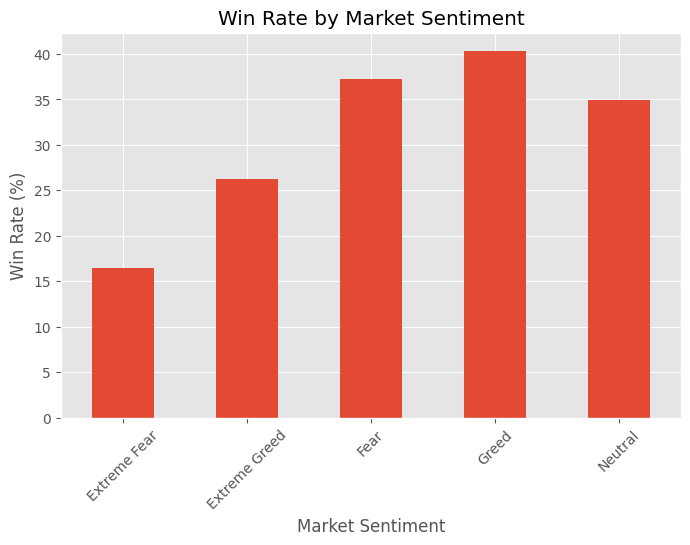

In [107]:
# Create Win/Loss column
merged["Win"] = merged["Closed PnL"] > 0

# Win Rate
win_rate = merged.groupby("classification")["Win"].mean() * 100

print(win_rate)

plt.figure(figsize=(8,5))
win_rate.plot(kind="bar")
plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=45)
plt.show()

# 5. Average Trading Size

In [108]:
fees = merged.groupby("classification")["Fee"].mean()

In [109]:
numeric_cols = ["Closed PnL", "Size USD", "Fee"]

for col in numeric_cols:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

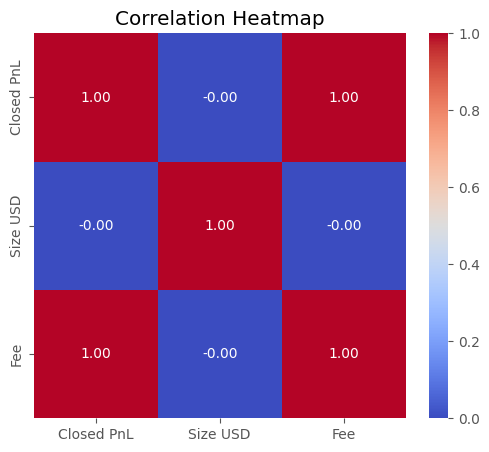

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = merged[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

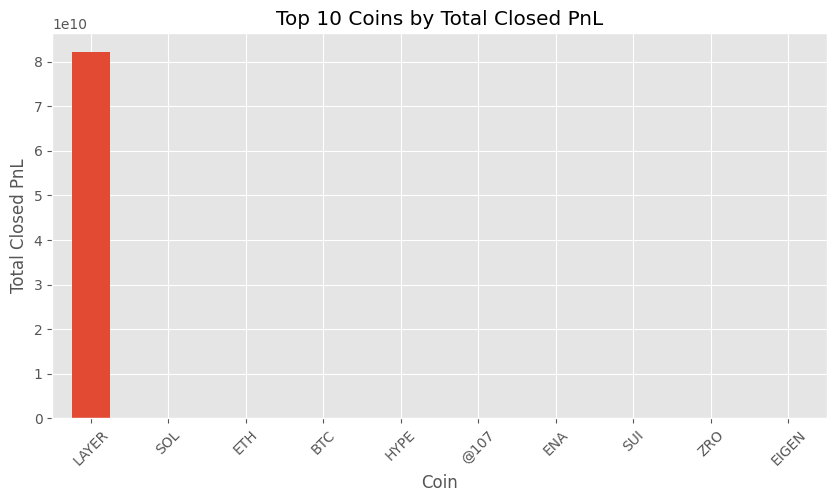

In [111]:
coin_profit = (
    merged.groupby("Coin")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
coin_profit.plot(kind="bar")
plt.title("Top 10 Coins by Total Closed PnL")
plt.xlabel("Coin")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45)
plt.show()

In [112]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date', 'date', 'classification', 'Win']


# Key Insights

- Trading activity varied across different Fear & Greed market conditions.
- Average profitability changed depending on market sentiment.
- Win rates were higher during some sentiment categories than others.
- Trading fees and trade sizes also differed across market conditions.
- Certain coins consistently generated higher profits than others.
- Market sentiment alone should not be used for trading decisions but can be a valuable input when combined with technical and risk-management strategies.

# Trading Strategy Recommendations

Based on the analysis:

- Monitor the Fear & Greed Index as an additional decision-making signal.
- Use tighter risk controls during sentiment conditions associated with lower profitability.
- Adjust position sizing according to market conditions rather than using a fixed size.
- Combine sentiment analysis with technical indicators before entering trades.
- Maintain disciplined stop-loss and take-profit rules regardless of market sentiment.

# Conclusion

This analysis explored the relationship between Bitcoin market sentiment and trader performance using Hyperliquid historical trading data and the Bitcoin Fear & Greed Index.

The results indicate that market sentiment is associated with changes in trading activity, profitability, and trading behavior. While sentiment provides useful context, it should be combined with technical analysis and sound risk management to build more effective trading strategies.

Overall, this project demonstrates how integrating external market indicators with historical trading data can generate actionable insights for data-driven trading decisions.

# Executive Summary

This project investigates the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using Hyperliquid historical trading data.

The analysis includes:
- Data cleaning and preprocessing
- Merging historical trader data with market sentiment
- Exploratory Data Analysis (EDA)
- Visualizations of trader performance
- Key insights and trading strategy recommendations

The objective is to understand how market sentiment influences trading behavior and profitability, helping traders make more informed decisions.

### Observation

Average trader profitability differs across market sentiment categories. This indicates that market sentiment may influence trading outcomes and should be considered alongside technical analysis.